In [4]:
# ── Standard library ─────────────────────────────────────────────────
import json
import logging
import os
import time
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

# ── Third-party ───────────────────────────────────────────────────────
import cv2
import numpy as np
import torch
from PIL import Image
from transformers import AutoProcessor, BitsAndBytesConfig, Qwen2VLForConditionalGeneration
from qwen_vl_utils import process_vision_info

# ── Logging ────────────────────────────────────────────────────────────
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

print("All imports successful.")

All imports successful.


In [5]:
# ── Model ─────────────────────────────────────────────────────────────
MODEL_NAME = "NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct"
MAX_NEW_TOKENS = 4000

# ── Input file ────────────────────────────────────────────────────────
# Change this to the path of your test document (image or PDF)
# FILE_PATH = "E:\\Anaconda3\\envs\\Judge-Assistant\\Case Sample\\Case_Sample_1.png"
FILE_PATH = "E:\\Anaconda3\\envs\\Judge-Assistant\\Case Sample\\Case_Sample(3).jpeg"

# ── PDF conversion DPI (only used for PDF files) ─────────────────────
PDF_DPI = 400

# ── Image restoration ─────────────────────────────────────────────────
MAX_IMAGE_DIMENSION = 4000
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)

# ── OCR prompt ────────────────────────────────────────────────────────
OCR_PROMPT = (
    "You are a strict OCR engine transcribing Arabic legal documents. "
    "Transcribe exactly what is written in this image. "
    "Do NOT correct spelling, grammar, punctuation, or any perceived mistakes. "
    "Do NOT add or remove any words. "
    "If something looks like a typo or error, transcribe it exactly as-is. "
    "Preserve all text exactly character by character."
)

# ── HuggingFace login ─────────────────────────────────────────────────
from huggingface_hub import login

if token := os.environ.get("HF_TOKEN"):
    login(token)
    print("HuggingFace login successful.")
else:
    print("HF_TOKEN not set — skipping login. Private models will not be accessible.")

print(f"Model: {MODEL_NAME}")
print(f"File:  {FILE_PATH}")

HF_TOKEN not set — skipping login. Private models will not be accessible.
Model: NAMAA-Space/Qari-OCR-v0.3-VL-2B-Instruct
File:  E:\Anaconda3\envs\Judge-Assistant\Case Sample\Case_Sample(3).jpeg


In [6]:
SUPPORTED_IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".tiff", ".bmp", ".webp"}
SUPPORTED_PDF_EXTENSIONS = {".pdf"}


def ingest_document(file_path: str, pdf_dpi: int = 400) -> List[Image.Image]:
    """
    Load a PDF or image file and return a list of PIL Images (one per page).
    """
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"File does not exist: {path}")
    if not path.is_file():
        raise ValueError(f"Path is not a file: {path}")

    suffix = path.suffix.lower()

    if suffix in SUPPORTED_PDF_EXTENSIONS:
        from pdf2image import convert_from_path
        print(f"Converting PDF to images at {pdf_dpi} DPI: {path.name}")
        pil_pages = convert_from_path(str(path), dpi=pdf_dpi)
        # Ensure RGB
        pages = [p.convert("RGB") if p.mode != "RGB" else p for p in pil_pages]
        print(f"PDF converted: {len(pages)} page(s)")
        return pages

    elif suffix in SUPPORTED_IMAGE_EXTENSIONS:
        print(f"Loading image: {path.name}")
        img = Image.open(path)
        img.verify()
        img = Image.open(path)  # re-open after verify
        if img.mode != "RGB":
            img = img.convert("RGB")
        print(f"Image loaded: {img.size[0]}x{img.size[1]}")
        return [img]

    else:
        raise ValueError(f"Unsupported file type: {suffix}")


# ── Run ingestion ─────────────────────────────────────────────────────
pages = ingest_document(FILE_PATH, pdf_dpi=PDF_DPI)
print(f"\nTotal pages: {len(pages)}")
for i, p in enumerate(pages):
    print(f"  Page {i + 1}: {p.size[0]}x{p.size[1]}")

Loading image: Case_Sample(3).jpeg
Image loaded: 899x1599

Total pages: 1
  Page 1: 899x1599


In [7]:
def restore_image(pil_image: Image.Image) -> Image.Image:
    """
    Lightweight image restoration:
    1. Convert to RGB if needed
    2. Resize if largest dimension > MAX_IMAGE_DIMENSION
    3. CLAHE contrast normalization
    """
    # 1. RGB conversion
    if pil_image.mode != "RGB":
        pil_image = pil_image.convert("RGB")

    # 2. Resize if too large
    w, h = pil_image.size
    max_dim = max(w, h)
    if max_dim > MAX_IMAGE_DIMENSION:
        scale = MAX_IMAGE_DIMENSION / max_dim
        new_w = int(w * scale)
        new_h = int(h * scale)
        pil_image = pil_image.resize((new_w, new_h), Image.LANCZOS)
        print(f"   Resized: {w}x{h} -> {new_w}x{new_h}")

    # 3. CLAHE contrast normalization
    img_array = np.array(pil_image)
    lab = cv2.cvtColor(img_array, cv2.COLOR_RGB2LAB)
    l_ch, a_ch, b_ch = cv2.split(lab)
    clahe = cv2.createCLAHE(
        clipLimit=CLAHE_CLIP_LIMIT,
        tileGridSize=CLAHE_TILE_GRID_SIZE,
    )
    l_enhanced = clahe.apply(l_ch)
    merged = cv2.merge((l_enhanced, a_ch, b_ch))
    enhanced_rgb = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

    return Image.fromarray(enhanced_rgb)


# ── Run restoration ───────────────────────────────────────────────────
restored_pages: List[Image.Image] = []
for i, page in enumerate(pages):
    print(f"Restoring page {i + 1}...")
    restored_pages.append(restore_image(page))

print(f"\nRestoration complete: {len(restored_pages)} page(s)")

Restoring page 1...

Restoration complete: 1 page(s)


Image size: 899x1599 (area=1,437,501)

Top 5 contours:
#             Area   % of image   Vertices   Passes area?   Is quad?
----------------------------------------------------------------------
0        1,133,066        78.8%          5              Y          N  
1            2,576         0.2%          6              N          N  
2            2,011         0.1%          8              N          N  
3            1,730         0.1%          6              N          N  
4            1,060         0.1%          5              N          N  

No clean quad found — falling back to minAreaRect on largest contour
  minAreaRect corners: [[-4.2005387e-14  2.2600000e+02]
 [ 8.9800000e+02  2.2600000e+02]
 [ 8.9800000e+02  1.5980000e+03]
 [ 0.0000000e+00  1.5980000e+03]]

Approach 2 succeeded
  Corners: [[-4.2005387e-14  2.2600000e+02]
 [ 8.9800000e+02  2.2600000e+02]
 [ 8.9800000e+02  1.5980000e+03]
 [ 0.0000000e+00  1.5980000e+03]]


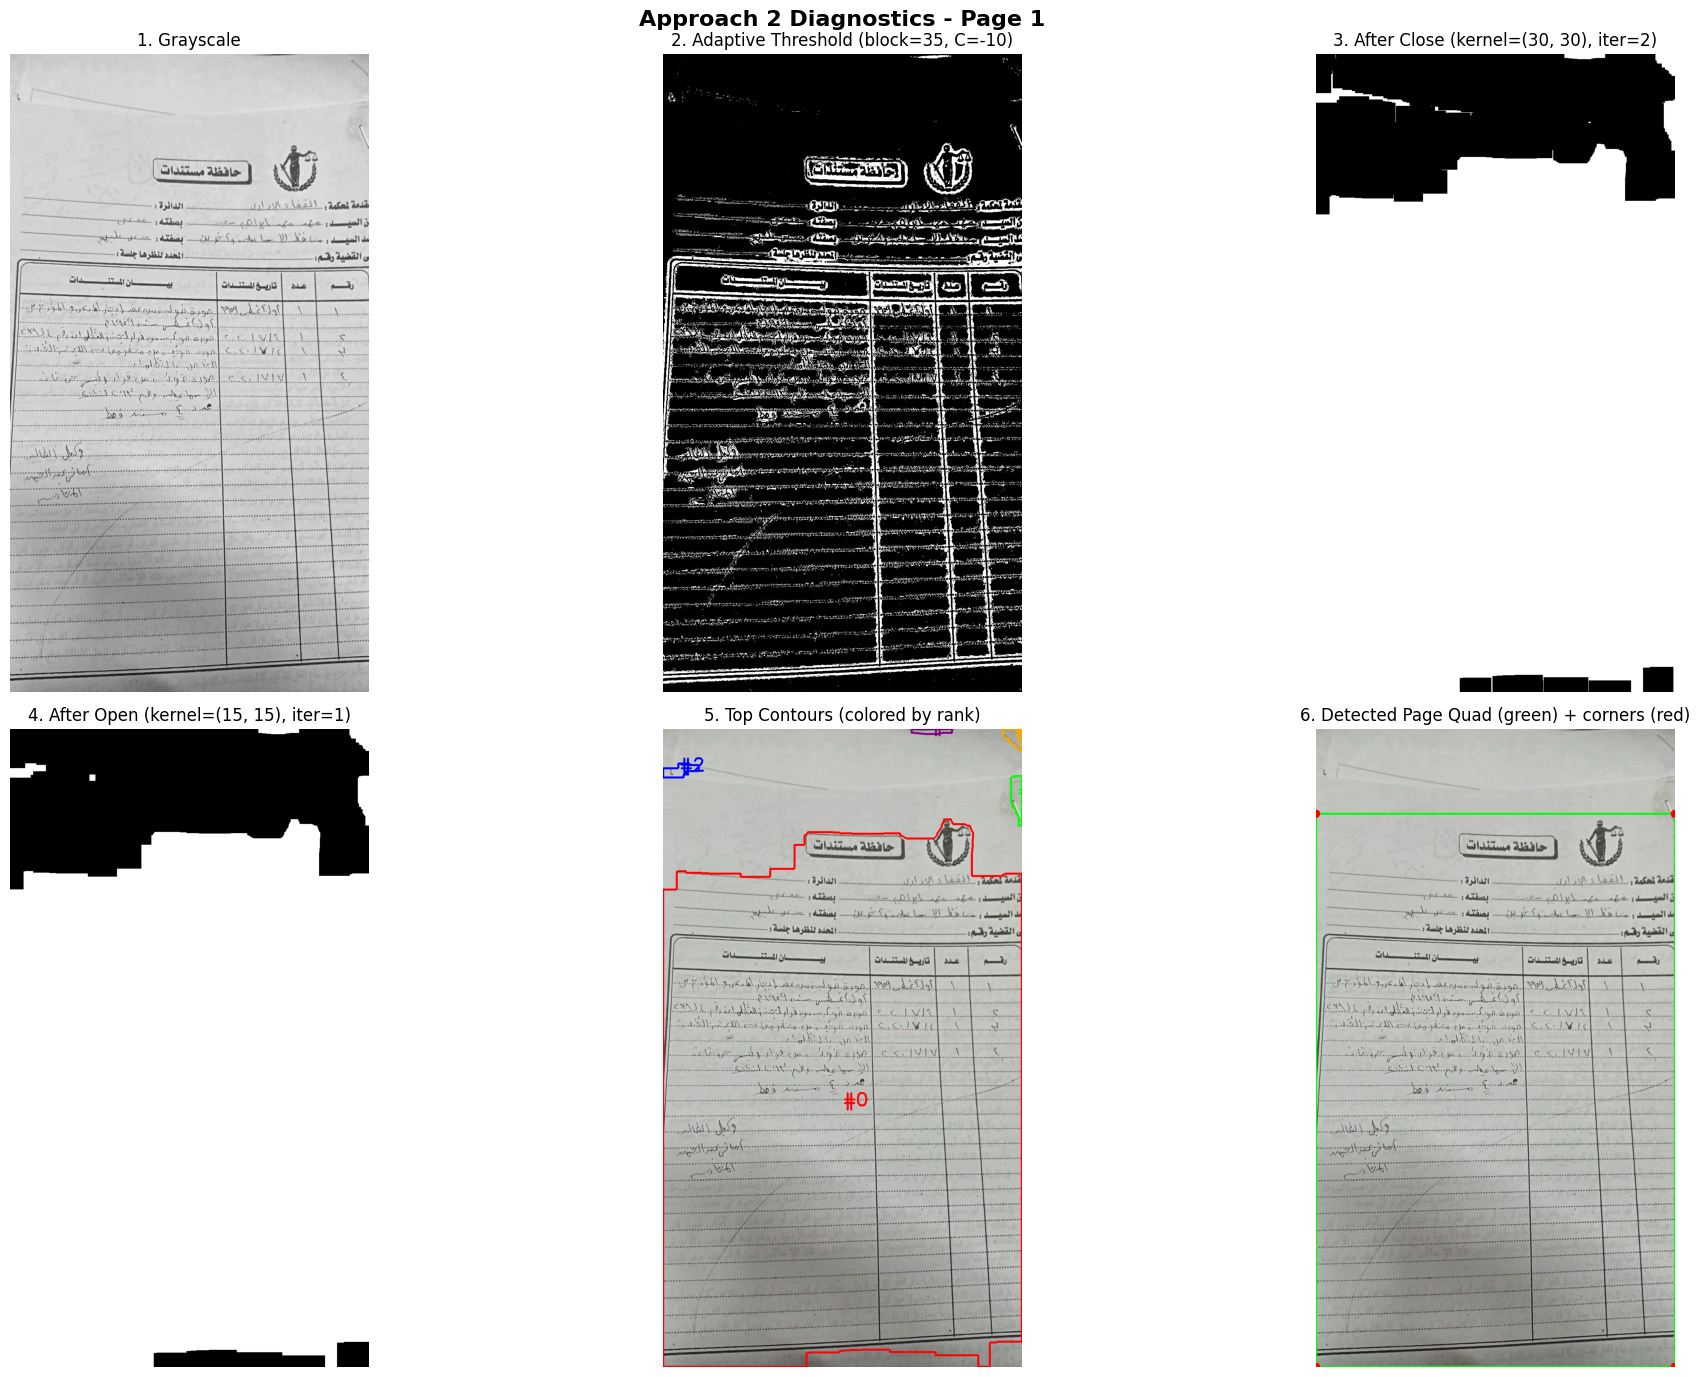

In [14]:
# ── Test: Approach 2 (Adaptive Threshold) Only ────────────────────────
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from typing import Optional, Tuple

# ── Config ─────────────────────────────────────────────────────────────
TEST_PAGE_INDEX    = 0      # which page to test
MIN_AREA_RATIO     = 0.35   # minimum contour area as fraction of image
BLOCK_SIZE         = 35     # adaptive threshold block size (must be odd)
C_CONSTANT         = -10    # threshold constant (more negative = stricter)
CLOSE_KERNEL       = (30, 30)  # morphological close kernel
CLOSE_ITERATIONS   = 2        # close iterations
OPEN_KERNEL        = (15, 15)   # morphological open kernel
OPEN_ITERATIONS    = 1        # open iterations
APPROX_EPSILON     = 0.02    # contour simplification tolerance
EXPAND_MARGIN      = 0.02     # quad expansion margin

# ── Helpers ─────────────────────────────────────────────────────────────
def order_points(pts: np.ndarray) -> np.ndarray:
    rect = np.zeros((4, 2), dtype=np.float32)
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    d = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(d)]
    rect[3] = pts[np.argmax(d)]
    return rect

def expand_quad(pts: np.ndarray, img_shape: Tuple, margin_pct: float) -> np.ndarray:
    h, w = img_shape[:2]
    center = pts.mean(axis=0)
    expanded = center + (pts - center) * (1 + margin_pct)
    expanded[:, 0] = np.clip(expanded[:, 0], 0, w - 1)
    expanded[:, 1] = np.clip(expanded[:, 1], 0, h - 1)
    return expanded.astype(np.float32)

# ── Approach 2 with full diagnostics ────────────────────────────────────
def test_approach_2(pil_image: Image.Image) -> Optional[np.ndarray]:
    img_array = np.array(pil_image)
    h, w = img_array.shape[:2]
    img_area = w * h

    print(f"Image size: {w}x{h} (area={img_area:,})")

    # Step 1: Grayscale
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)

    # Step 2: Adaptive threshold
    binary = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        BLOCK_SIZE, C_CONSTANT
    )

    # Step 3: Morphological close
    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, CLOSE_KERNEL)
    binary_closed = cv2.morphologyEx(
        binary, cv2.MORPH_CLOSE, kernel_close, iterations=CLOSE_ITERATIONS
    )

    # Step 4: Morphological open
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, OPEN_KERNEL)
    binary_final = cv2.morphologyEx(
        binary_closed, cv2.MORPH_OPEN, kernel_open, iterations=OPEN_ITERATIONS
    )

    # Step 5: Contours
    contours, _ = cv2.findContours(
        binary_final, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        print("No contours found after thresholding.")
        return None

    # Sort and print all significant contours
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    print(f"\nTop {min(5, len(contours))} contours:")
    print(f"{'#':<5} {'Area':>12} {'% of image':>12} {'Vertices':>10} {'Passes area?':>14} {'Is quad?':>10}")
    print("-" * 70)

    found_quad = None
    for i, contour in enumerate(contours[:5]):
        area        = cv2.contourArea(contour)
        area_pct    = 100 * area / img_area
        passes_area = area >= img_area * MIN_AREA_RATIO
        peri        = cv2.arcLength(contour, True)
        approx      = cv2.approxPolyDP(contour, APPROX_EPSILON * peri, True)
        is_quad     = len(approx) == 4
        marker      = "<-- SELECTED" if (passes_area and is_quad and found_quad is None) else ""

        print(
            f"{i:<5} {area:>12,.0f} {area_pct:>11.1f}% {len(approx):>10} "
            f"{'Y' if passes_area else 'N':>14} {'Y' if is_quad else 'N':>10}  {marker}"
        )

        if passes_area and is_quad and found_quad is None:
            found_quad = approx.reshape(4, 2)

    # If no clean quad, try minAreaRect on largest
    if found_quad is None:
        largest = contours[0]
        largest_area = cv2.contourArea(largest)
        if largest_area >= img_area * MIN_AREA_RATIO:
            print(f"\nNo clean quad found — falling back to minAreaRect on largest contour")
            rect = cv2.minAreaRect(largest)
            box  = cv2.boxPoints(rect)
            found_quad = box.astype(np.float32)
            print(f"  minAreaRect corners: {found_quad}")
        else:
            print(f"\nApproach 2 failed — largest contour too small ({100*largest_area/img_area:.1f}%)")
            return None

    if found_quad is not None:
        print(f"\nApproach 2 succeeded")
        print(f"  Corners: {found_quad}")

    return found_quad


# ── Run test ─────────────────────────────────────────────────────────────
test_image = restored_pages[TEST_PAGE_INDEX]
img_array  = np.array(test_image)
h, w       = img_array.shape[:2]

# Run all intermediate steps for visualization
gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
binary = cv2.adaptiveThreshold(
    gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY, BLOCK_SIZE, C_CONSTANT
)
kernel_close  = cv2.getStructuringElement(cv2.MORPH_RECT, CLOSE_KERNEL)
binary_closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel_close, iterations=CLOSE_ITERATIONS)
kernel_open   = cv2.getStructuringElement(cv2.MORPH_RECT, OPEN_KERNEL)
binary_final  = cv2.morphologyEx(binary_closed, cv2.MORPH_OPEN, kernel_open, iterations=OPEN_ITERATIONS)

page_quad = test_approach_2(test_image)

# ── Visualization ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 14))

axes[0][0].imshow(gray, cmap='gray')
axes[0][0].set_title('1. Grayscale')
axes[0][0].axis('off')

axes[0][1].imshow(binary, cmap='gray')
axes[0][1].set_title(f'2. Adaptive Threshold (block={BLOCK_SIZE}, C={C_CONSTANT})')
axes[0][1].axis('off')

axes[0][2].imshow(binary_closed, cmap='gray')
axes[0][2].set_title(f'3. After Close (kernel={CLOSE_KERNEL}, iter={CLOSE_ITERATIONS})')
axes[0][2].axis('off')

axes[1][0].imshow(binary_final, cmap='gray')
axes[1][0].set_title(f'4. After Open (kernel={OPEN_KERNEL}, iter={OPEN_ITERATIONS})')
axes[1][0].axis('off')

# All top contours drawn on original
contours_vis, _ = cv2.findContours(
    binary_final, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)
contours_vis = sorted(contours_vis, key=cv2.contourArea, reverse=True)
contour_overlay = img_array.copy()
colors = [(255,0,0), (0,255,0), (0,0,255), (255,165,0), (128,0,128)]
for i, cnt in enumerate(contours_vis[:5]):
    cv2.drawContours(contour_overlay, [cnt], -1, colors[i], 3)
    M = cv2.moments(cnt)
    if M['m00'] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
        cv2.putText(
            contour_overlay, f'#{i}', (cx, cy),
            cv2.FONT_HERSHEY_SIMPLEX, 1.5, colors[i], 3
        )
axes[1][1].imshow(contour_overlay)
axes[1][1].set_title('5. Top Contours (colored by rank)')
axes[1][1].axis('off')

# Final result overlay
result_overlay = img_array.copy()
if page_quad is not None:
    expanded = expand_quad(page_quad.astype(np.float32), img_array.shape, EXPAND_MARGIN)
    pts_int  = expanded.astype(np.int32).reshape((-1, 1, 2))
    cv2.polylines(result_overlay, [pts_int], isClosed=True, color=(0,255,0), thickness=4)
    for pt in expanded.astype(np.int32):
        cv2.circle(result_overlay, tuple(pt), 10, (255,0,0), -1)
    axes[1][2].set_title('6. Detected Page Quad (green) + corners (red)')
else:
    axes[1][2].set_title('6. No Quad Detected')
axes[1][2].imshow(result_overlay)
axes[1][2].axis('off')

plt.suptitle(
    f'Approach 2 Diagnostics - Page {TEST_PAGE_INDEX + 1}',
    fontsize=16, fontweight='bold'
)
plt.tight_layout()
plt.show()

Input:  899x1599
Output: 898x1385
Ratio:  w=1.00, h=0.87


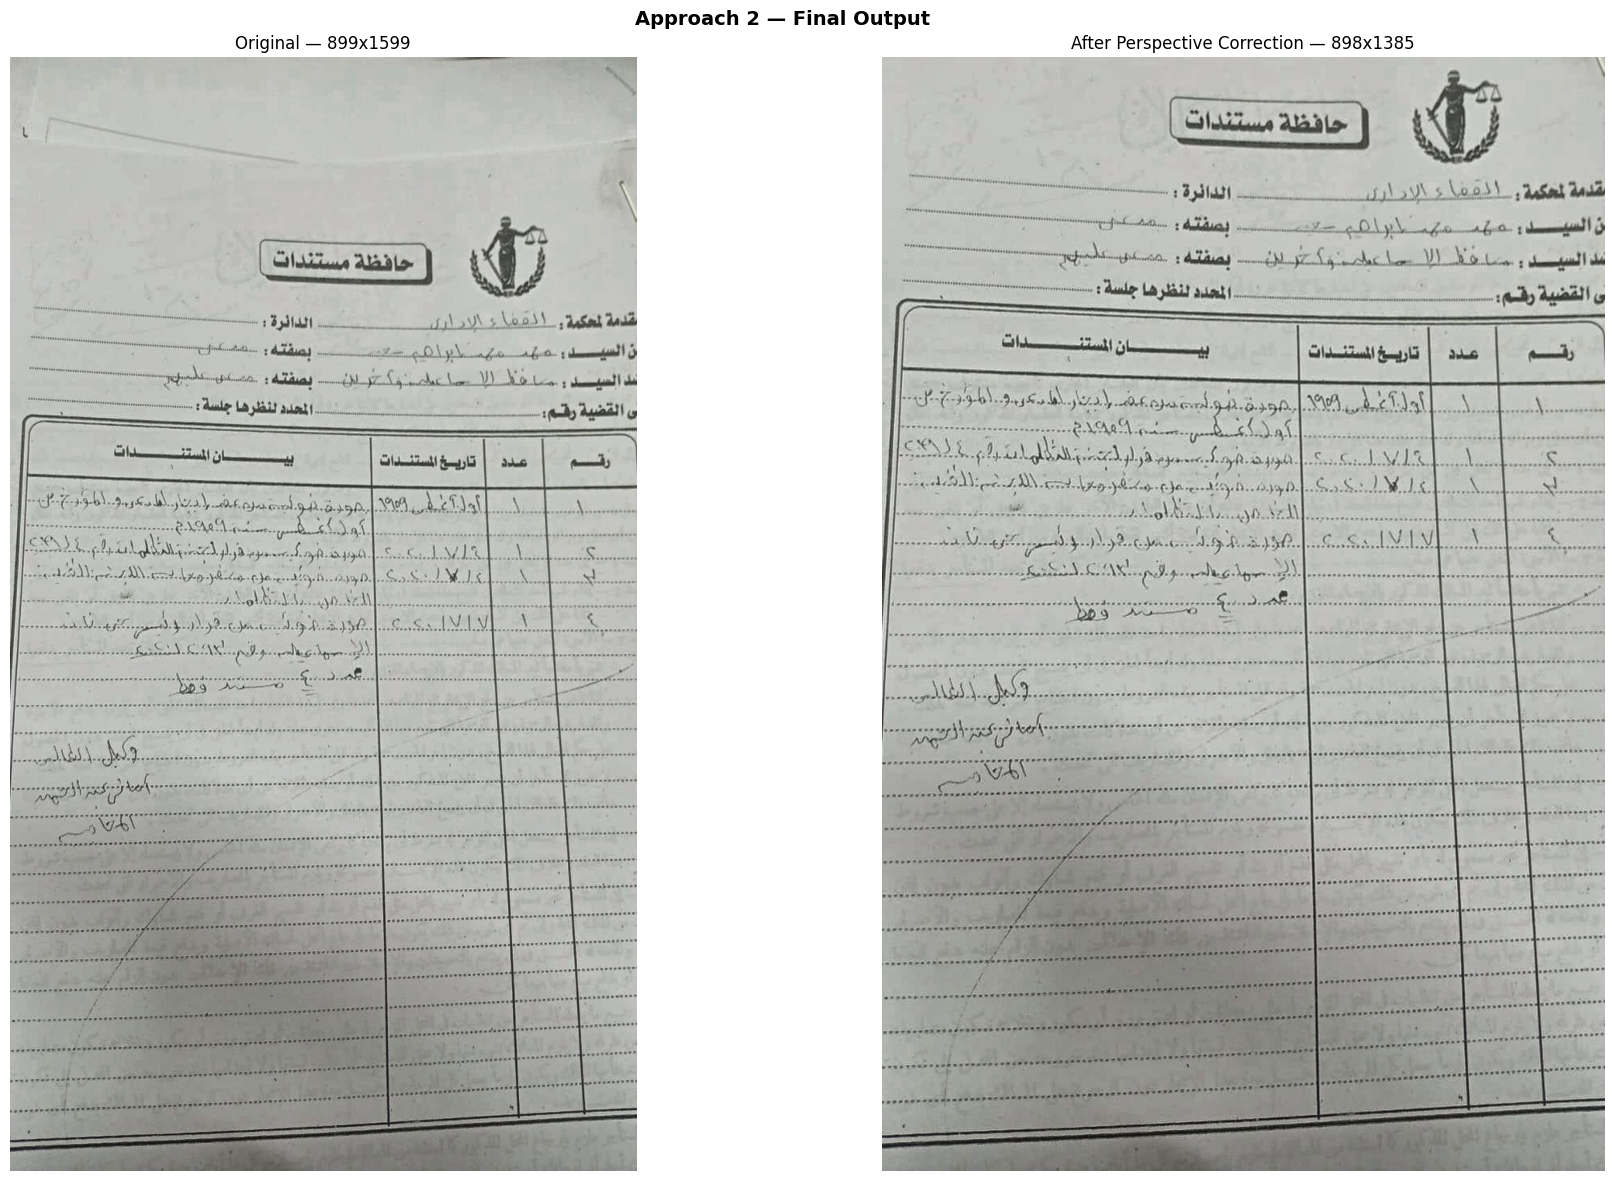

In [15]:
# ── Approach 2 — Final Output Preview ─────────────────────────────────
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt

if page_quad is None:
    print("No quad detected — nothing to show.")
else:
    # Apply expand
    expanded = expand_quad(page_quad.astype(np.float32), img_array.shape, EXPAND_MARGIN)
    src_pts  = order_points(expanded)

    # Compute output dimensions
    dst_w = int(max(
        np.linalg.norm(src_pts[1] - src_pts[0]),
        np.linalg.norm(src_pts[2] - src_pts[3]),
    ))
    dst_h = int(max(
        np.linalg.norm(src_pts[3] - src_pts[0]),
        np.linalg.norm(src_pts[2] - src_pts[1]),
    ))

    print(f"Input:  {w}x{h}")
    print(f"Output: {dst_w}x{dst_h}")
    print(f"Ratio:  w={dst_w/w:.2f}, h={dst_h/h:.2f}")

    dst_pts = np.array([
        [0,         0        ],
        [dst_w - 1, 0        ],
        [dst_w - 1, dst_h - 1],
        [0,         dst_h - 1],
    ], dtype=np.float32)

    M      = cv2.getPerspectiveTransform(src_pts, dst_pts)
    warped = cv2.warpPerspective(
        img_array, M, (dst_w, dst_h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(255, 255, 255),
    )

    # Show side by side
    fig, axes = plt.subplots(1, 2, figsize=(20, 12))

    axes[0].imshow(img_array)
    axes[0].set_title(f'Original — {w}x{h}')
    axes[0].axis('off')

    axes[1].imshow(warped)
    axes[1].set_title(f'After Perspective Correction — {dst_w}x{dst_h}')
    axes[1].axis('off')

    plt.suptitle('Approach 2 — Final Output', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [13]:
# ── Config ─────────────────────────────────────────────────────────────
MIN_OUTPUT_DIM        = 100   # minimum width/height in pixels
MIN_DIM_RATIO         = 0.65  # minimum width/height ratio vs original
ASPECT_RATIO_TOLERANCE = 1.15 # max W/H if portrait flips to landscape


# ── Safety Guard Test (Diagnostic Version) ─────────────────────────────
def test_safety_guards(
    src_pts: np.ndarray,
    dst_w: int,
    dst_h: int,
    orig_w: int,
    orig_h: int,
) -> Tuple[bool, str]:

    print("\n── Safety Guard Diagnostics ─────────────────────────────")

    print(f"Original size : {orig_w} x {orig_h}")
    print(f"Output size   : {dst_w} x {dst_h}")

    # ── Step 1: Minimum dimension check ─────────────────────────────
    print(f"\n[1] Minimum dimension check (>= {MIN_OUTPUT_DIM}px)")
    if dst_w < MIN_OUTPUT_DIM or dst_h < MIN_OUTPUT_DIM:
        print(f"❌ FAILED → Output too small ({dst_w}x{dst_h})")
        return False, f'output too small ({dst_w}x{dst_h})'
    print("✓ Passed")

    # ── Step 2: Crop ratio check ────────────────────────────────────
    print("\n[2] Crop ratio check")
    w_ratio = dst_w / orig_w
    h_ratio = dst_h / orig_h

    print(f"Width ratio  : {w_ratio:.3f} (min required: {MIN_DIM_RATIO})")
    print(f"Height ratio : {h_ratio:.3f} (min required: {MIN_DIM_RATIO})")

    if w_ratio < MIN_DIM_RATIO or h_ratio < MIN_DIM_RATIO:
        print("❌ FAILED → Crops too aggressively")
        return False, f'crops too aggressively (w_ratio={w_ratio:.2f}, h_ratio={h_ratio:.2f})'
    print("✓ Passed")

    # ── Step 3: Area ratio check ────────────────────────────────────
    print("\n[3] Area ratio check")
    area_ratio = (dst_w * dst_h) / (orig_w * orig_h)
    print(f"Area ratio   : {area_ratio:.3f} (min required: {MIN_AREA_RATIO})")

    if area_ratio < MIN_AREA_RATIO:
        print("❌ FAILED → Output area too small")
        return False, f'output area too small ({area_ratio:.2f} of original)'
    print("✓ Passed")

    # ── Step 4: Aspect ratio sanity ─────────────────────────────────
    print("\n[4] Aspect ratio sanity check")

    orig_portrait = orig_h > orig_w
    out_portrait  = dst_h > dst_w

    print(f"Original orientation : {'Portrait' if orig_portrait else 'Landscape'}")
    print(f"Output orientation   : {'Portrait' if out_portrait else 'Landscape'}")

    if orig_portrait and not out_portrait:
        ratio = dst_w / dst_h
        print(f"Output W/H ratio     : {ratio:.3f} (threshold: {ASPECT_RATIO_TOLERANCE})")

        if ratio > ASPECT_RATIO_TOLERANCE:
            print("❌ FAILED → Portrait became landscape")
            return False, 'portrait original became landscape output'

    print("✓ Passed")

    # ── Final Result ────────────────────────────────────────────────
    print("\n✓ ALL SAFETY CHECKS PASSED")

    return True, 'ok'